In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [4]:
file_path = "../data/raw/online_retail_II.xlsx"

excel_file = pd.ExcelFile(file_path)

print(excel_file.sheet_names)

['Year 2009-2010', 'Year 2010-2011']


In [5]:
df = pd.read_excel(file_path, sheet_name=excel_file.sheet_names[0])

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


In [8]:
df.describe(include="all")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,525461.0,525461,522533,525461.000000,525461,525461.000000,417534.000000,525461
unique,28816.0,4632,4681,NaN,NaN,NaN,NaN,40
top,537434.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,675.0,3516,3549,NaN,NaN,NaN,NaN,485852
mean,NaN,NaN,NaN,10.337667,2010-06-28 11:37:36.845018,4.688834,15360.645478,NaN
min,NaN,NaN,NaN,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2010-03-21 12:20:00,1.250000,13983.000000,NaN
50%,NaN,NaN,NaN,3.000000,2010-07-06 09:51:00,2.100000,15311.000000,NaN
75%,NaN,NaN,NaN,10.000000,2010-10-15 12:45:00,4.210000,16799.000000,NaN
max,NaN,NaN,NaN,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000,NaN


In [9]:
missing_values = df.isna().sum()

print(missing_values)

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [10]:
missing_percentage = (df.isna().sum() / len(df)) * 100

print(missing_percentage.sort_values(ascending=False))

Customer ID    20.539488
Description     0.557225
StockCode       0.000000
Invoice         0.000000
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Country         0.000000
dtype: float64


In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 6865


In [12]:
print("Columns:")
for column in df.columns:
    print("-", column)

Columns:
- Invoice
- StockCode
- Description
- Quantity
- InvoiceDate
- Price
- Customer ID
- Country


In [13]:
print("Unique invoices:", df["Invoice"].nunique())
print("Unique products:", df["StockCode"].nunique())
print("Unique customers:", df["Customer ID"].nunique())
print("Unique countries:", df["Country"].nunique())

Unique invoices: 28816
Unique products: 4632
Unique customers: 4383
Unique countries: 40


In [14]:
print(df["Country"].value_counts())

Country
United Kingdom          485852
EIRE                      9670
Germany                   8129
France                    5772
Netherlands               2769
Spain                     1278
Switzerland               1187
Portugal                  1101
Belgium                   1054
Channel Islands            906
Sweden                     902
Italy                      731
Australia                  654
Cyprus                     554
Austria                    537
Greece                     517
United Arab Emirates       432
Denmark                    428
Norway                     369
Finland                    354
Unspecified                310
USA                        244
Japan                      224
Poland                     194
Malta                      172
Lithuania                  154
Singapore                  117
RSA                        111
Bahrain                    107
Canada                      77
Hong Kong                   76
Thailand                    76


In [15]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Start date:", df["InvoiceDate"].min())
print("End date:", df["InvoiceDate"].max())

Start date: 2009-12-01 07:45:00
End date: 2010-12-09 20:01:00


In [16]:
print("Negative quantity:", (df["Quantity"] < 0).sum())
print("Zero quantity:", (df["Quantity"] == 0).sum())

print("Negative price:", (df["Price"] < 0).sum())
print("Zero price:", (df["Price"] == 0).sum())

Negative quantity: 12326
Zero quantity: 0
Negative price: 3
Zero price: 3687


In [17]:
df_2 = pd.read_excel(
    file_path,
    sheet_name=excel_file.sheet_names[1]
)

print("Second sheet loaded successfully!")
print("Shape:", df_2.shape)

df_2.head()

Second sheet loaded successfully!
Shape: (541910, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [18]:
print("First sheet columns:")
print(df.columns.tolist())

print("\nSecond sheet columns:")
print(df_2.columns.tolist())

First sheet columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Second sheet columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [19]:
print("First sheet date range:")
print(df["InvoiceDate"].min(), "to", df["InvoiceDate"].max())

print("\nSecond sheet date range:")
print(df_2["InvoiceDate"].min(), "to", df_2["InvoiceDate"].max())

First sheet date range:
2009-12-01 07:45:00 to 2010-12-09 20:01:00

Second sheet date range:
2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [20]:
df = pd.concat(
    [df, df_2],
    ignore_index=True
)

print("Combined dataset shape:", df.shape)

Combined dataset shape: (1067371, 8)


In [21]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [22]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [23]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [24]:
print(df["InvoiceDate"].dtype)

datetime64[us]


In [25]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nUnique invoices:", df["Invoice"].nunique())
print("Unique products:", df["StockCode"].nunique())
print("Unique customers:", df["Customer ID"].nunique())
print("Unique countries:", df["Country"].nunique())

print("\nDate range:")
print(df["InvoiceDate"].min(), "to", df["InvoiceDate"].max())

Rows: 1067371
Columns: 8

Unique invoices: 53628
Unique products: 5305
Unique customers: 5942
Unique countries: 43

Date range:
2009-12-01 07:45:00 to 2011-12-09 12:50:00


In [26]:
missing = df.isna().sum().sort_values(ascending=False)

print(missing)

Customer ID    243007
Description      4382
StockCode           0
Invoice             0
Quantity            0
InvoiceDate         0
Price               0
Country             0
dtype: int64


In [27]:
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)

print(missing_pct)

Customer ID    22.766873
Description     0.410541
StockCode       0.000000
Invoice         0.000000
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Country         0.000000
dtype: float64


In [28]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 34335


In [29]:
duplicate_pct = duplicate_count / len(df) * 100

print(f"Duplicate percentage: {duplicate_pct:.2f}%")

Duplicate percentage: 3.22%


In [30]:
print("Negative quantity:", (df["Quantity"] < 0).sum())
print("Zero quantity:", (df["Quantity"] == 0).sum())
print("Positive quantity:", (df["Quantity"] > 0).sum())

Negative quantity: 22950
Zero quantity: 0
Positive quantity: 1044421


In [31]:
df[df["Quantity"] < 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [32]:
print("Negative price:", (df["Price"] < 0).sum())
print("Zero price:", (df["Price"] == 0).sum())
print("Positive price:", (df["Price"] > 0).sum())

Negative price: 5
Zero price: 6202
Positive price: 1061164


In [33]:
df[df["Price"] == 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom


In [34]:
print(df["Invoice"].dtype)

object


In [35]:
invoice_str = df["Invoice"].astype(str)

cancelled_rows = invoice_str.str.startswith("C")

print("Cancelled transaction rows:", cancelled_rows.sum())

Cancelled transaction rows: 19494


In [36]:
df[cancelled_rows].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [37]:
missing_customer = df["Customer ID"].isna().sum()

print("Missing Customer ID:", missing_customer)
print(
    f"Missing Customer ID %: "
    f"{missing_customer / len(df) * 100:.2f}%"
)

Missing Customer ID: 243007
Missing Customer ID %: 22.77%


In [38]:
missing_description = df["Description"].isna().sum()

print("Missing Description:", missing_description)

Missing Description: 4382


In [39]:
print(df["StockCode"].value_counts().head(20))

StockCode
85123A    5829
22423     4424
85099B    4216
21212     3318
20725     3259
84879     2960
47566     2768
21232     2747
22197     2549
22383     2540
20727     2529
21931     2434
22386     2347
22469     2325
22411     2297
84991     2271
22382     2251
22384     2230
21080     2224
22086     2217
Name: count, dtype: int64


In [40]:
print(df["Description"].value_counts().head(20))

Description
WHITE HANGING HEART T-LIGHT HOLDER    5918
REGENCY CAKESTAND 3 TIER              4412
JUMBO BAG RED RETROSPOT               3469
ASSORTED COLOUR BIRD ORNAMENT         2958
PARTY BUNTING                         2765
STRAWBERRY CERAMIC TRINKET BOX        2613
LUNCH BAG  BLACK SKULL.               2529
JUMBO STORAGE BAG SUKI                2434
HEART OF WICKER SMALL                 2319
JUMBO SHOPPER VINTAGE RED PAISLEY     2297
60 TEATIME FAIRY CAKE CASES           2271
PAPER CHAIN KIT 50'S CHRISTMAS        2215
LUNCH BAG SPACEBOY DESIGN             2206
REX CASH+CARRY JUMBO SHOPPER          2199
HOME BUILDING BLOCK WORD              2192
WOODEN FRAME ANTIQUE WHITE            2189
LUNCH BAG CARS BLUE                   2184
NATURAL SLATE HEART CHALKBOARD        2151
BAKING SET 9 PIECE RETROSPOT          2150
POSTAGE                               2115
Name: count, dtype: int64


In [41]:
invoice_str = df["Invoice"].astype(str)

is_cancelled = invoice_str.str.startswith("C")
is_negative_qty = df["Quantity"] < 0

print("Total cancelled rows:", is_cancelled.sum())
print("Total negative quantity rows:", is_negative_qty.sum())

print("\nCancelled AND negative quantity:",
      (is_cancelled & is_negative_qty).sum())

print("\nCancelled BUT positive quantity:",
      (is_cancelled & ~is_negative_qty).sum())

print("\nNegative quantity BUT NOT cancelled:",
      (~is_cancelled & is_negative_qty).sum())

Total cancelled rows: 19494
Total negative quantity rows: 22950

Cancelled AND negative quantity: 19493

Cancelled BUT positive quantity: 1

Negative quantity BUT NOT cancelled: 3457


In [42]:
df[(~is_cancelled) & (df["Quantity"] < 0)].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom
4538,489820,21133,invcd as 84879?,-720,2009-12-02 13:23:00,0.0,NaN,United Kingdom
4566,489821,85049G,NaN,-240,2009-12-02 13:25:00,0.0,NaN,United Kingdom


In [43]:
df[df["Price"] == 0].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom


In [44]:
print(df[df["Price"] == 0]["Description"].value_counts().head(20))

Description
check                                  162
?                                       92
damages                                 84
damaged                                 81
found                                   28
missing                                 27
sold as set on dotcom                   20
Damaged                                 17
adjustment                              16
OWL DOORSTOP                            15
POLYESTER FILLER PAD 45x45cm            12
dotcom                                  12
amazon                                  11
POLYESTER FILLER PAD 40x40cm            10
IVORY KITCHEN SCALES                    10
FRENCH BLUE METAL DOOR SIGN 1           10
smashed                                  9
Found                                    9
PICNIC BASKET WICKER LARGE               9
AIRLINE BAG VINTAGE WORLD CHAMPION       9
Name: count, dtype: int64


In [45]:
missing_customer_mask = df["Customer ID"].isna()

print("Rows with missing customer:")
print(missing_customer_mask.sum())

print("\nRevenue-related quantity:")
print(df.loc[missing_customer_mask, "Quantity"].sum())

print("\nCountries:")
print(df.loc[missing_customer_mask, "Country"].value_counts().head(10))

Rows with missing customer:
243007

Revenue-related quantity:
374364

Countries:
Country
United Kingdom          240029
EIRE                      1671
Hong Kong                  364
Unspecified                232
France                     128
Switzerland                125
Portugal                   116
United Arab Emirates       114
Bahrain                     67
Israel                      47
Name: count, dtype: int64


In [46]:
duplicates = df[df.duplicated(keep=False)]

duplicates.head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom


In [47]:
duplicates.sort_values(
    ["Invoice", "StockCode", "InvoiceDate"]
).head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom


In [48]:
df[is_cancelled & ~is_negative_qty]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
76799,C496350,M,Manual,1,2010-02-01 08:24:00,373.57,NaN,United Kingdom


In [49]:
df[(~is_cancelled) & is_negative_qty].head(30)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom
4538,489820,21133,invcd as 84879?,-720,2009-12-02 13:23:00,0.0,NaN,United Kingdom
4566,489821,85049G,NaN,-240,2009-12-02 13:25:00,0.0,NaN,United Kingdom


In [50]:
df[(df["Price"] == 0) & (df["Quantity"] > 0)].head(30)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126.0,United Kingdom
5904,489861,DOT,DOTCOM POSTAGE,1,2009-12-02 14:50:00,0.0,NaN,United Kingdom
6378,489882,35751C,NaN,12,2009-12-02 16:22:00,0.0,NaN,United Kingdom
6555,489898,79323G,NaN,954,2009-12-03 09:40:00,0.0,NaN,United Kingdom
6581,489903,21166,NaN,48,2009-12-03 09:57:00,0.0,NaN,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.0,15658.0,United Kingdom
7204,490015,21982,NaN,467,2009-12-03 12:29:00,0.0,NaN,United Kingdom
9249,490123,84508B,NaN,184,2009-12-03 18:08:00,0.0,NaN,United Kingdom


In [51]:
df["RawRevenue"] = df["Quantity"] * df["Price"]

print("Raw revenue:")
print(df["RawRevenue"].sum())

Raw revenue:
19287250.568


In [52]:
print("Positive revenue rows:",
      (df["RawRevenue"] > 0).sum())

print("Negative revenue rows:",
      (df["RawRevenue"] < 0).sum())

print("Zero revenue rows:",
      (df["RawRevenue"] == 0).sum())

Positive revenue rows: 1041671
Negative revenue rows: 19498
Zero revenue rows: 6202


In [53]:
print(
    "Cancelled duplicate rows:",
    df[is_cancelled].duplicated().sum()
)

print(
    "Non-cancelled duplicate rows:",
    df[~is_cancelled].duplicated().sum()
)

Cancelled duplicate rows: 390
Non-cancelled duplicate rows: 33945


In [54]:
print(
    "Negative non-cancelled revenue:",
    df[(~is_cancelled) & (df["Quantity"] < 0)]["RawRevenue"].sum()
)

print(
    "Cancelled revenue:",
    df[is_cancelled]["RawRevenue"].sum()
)

Negative non-cancelled revenue: 0.0
Cancelled revenue: -1526667.86


In [55]:
clean_df = pd.read_csv(
    "../data/processed/clean_transactions.csv"
)

print("Clean dataset shape:", clean_df.shape)

Clean dataset shape: (1013932, 12)


C:\Users\rathi\AppData\Local\Temp\ipykernel_26308\3101666446.py:1: DtypeWarning: Columns (0: Invoice) have mixed types. Specify dtype option on import or set low_memory=False.
  clean_df = pd.read_csv(


In [56]:
is_cancelled_clean = (
    clean_df["Invoice"]
    .astype(str)
    .str.startswith("C")
)

print(
    "Cancelled rows remaining:",
    is_cancelled_clean.sum()
)

Cancelled rows remaining: 0


In [57]:
print(
    "Duplicate rows remaining:",
    clean_df.duplicated().sum()
)

Duplicate rows remaining: 0


In [58]:
revenue_check = (
    clean_df["Quantity"] * clean_df["Price"]
)

print(
    "Incorrect revenue rows:",
    (clean_df["Revenue"] != revenue_check).sum()
)

Incorrect revenue rows: 93141


In [59]:
print(clean_df.dtypes)

Invoice           object
StockCode            str
Description          str
Quantity           int64
InvoiceDate          str
Price            float64
Customer ID      float64
Country              str
is_cancelled        bool
is_return           bool
is_zero_price       bool
Revenue          float64
dtype: object


In [60]:
negative_revenue_df = clean_df[
    clean_df["Revenue"] < 0
]

negative_revenue_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancelled,is_return,is_zero_price,Revenue
173672,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom,False,False,False,-53594.36
267124,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom,False,False,False,-44031.79
390426,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom,False,False,False,-38925.87
778751,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,False,False,False,-11062.06
778752,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,False,False,False,-11062.06


In [61]:
print(
    negative_revenue_df[
        [
            "Invoice",
            "StockCode",
            "Description",
            "Quantity",
            "Price",
            "Customer ID",
            "Revenue",
            "is_return",
            "is_cancelled"
        ]
    ]
)

        Invoice StockCode      Description  Quantity     Price  Customer ID  \
173672  A506401         B  Adjust bad debt         1 -53594.36          NaN   
267124  A516228         B  Adjust bad debt         1 -44031.79          NaN   
390426  A528059         B  Adjust bad debt         1 -38925.87          NaN   
778751  A563186         B  Adjust bad debt         1 -11062.06          NaN   
778752  A563187         B  Adjust bad debt         1 -11062.06          NaN   

         Revenue  is_return  is_cancelled  
173672 -53594.36      False         False  
267124 -44031.79      False         False  
390426 -38925.87      False         False  
778751 -11062.06      False         False  
778752 -11062.06      False         False  


In [62]:
print(
    "Returns:",
    clean_df["is_return"].sum()
)

print(
    "Negative quantity rows:",
    (clean_df["Quantity"] < 0).sum()
)

Returns: 3393
Negative quantity rows: 3393


In [63]:
negative_price_df = df[df["Price"] < 0]

print(
    "Negative price rows:",
    len(negative_price_df)
)

print(
    "Negative price total impact:",
    negative_price_df["RawRevenue"].sum()
)

negative_price_df[
    [
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "Price",
        "Customer ID",
        "Country",
        "RawRevenue"
    ]
].head(30)

Negative price rows: 5
Negative price total impact: -158676.13999999998


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,RawRevenue
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom,-53594.36
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom,-44031.79
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom,-38925.87
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,-11062.06
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,-11062.06


In [64]:
print(
    negative_price_df["Description"]
    .value_counts()
    .head(30)
)

Description
Adjust bad debt    5
Name: count, dtype: int64


In [65]:
print(
    negative_price_df[
        ["Description", "Quantity", "Price", "RawRevenue"]
    ].describe()
)

       Quantity         Price    RawRevenue
count       5.0      5.000000      5.000000
mean        1.0 -31735.228000 -31735.228000
std         0.0  19592.678298  19592.678298
min         1.0 -53594.360000 -53594.360000
25%         1.0 -44031.790000 -44031.790000
50%         1.0 -38925.870000 -38925.870000
75%         1.0 -11062.060000 -11062.060000
max         1.0 -11062.060000 -11062.060000


In [66]:
print(
    negative_price_df.groupby("Description")["RawRevenue"]
    .agg(["count", "sum"])
    .sort_values("sum")
    .head(20)
)

                 count        sum
Description                      
Adjust bad debt      5 -158676.14


In [67]:
import numpy as np

clean_df = pd.read_csv(
    "../data/processed/clean_transactions.csv"
)

print("Clean dataset shape:", clean_df.shape)

Clean dataset shape: (1013926, 13)


In [68]:
# Convert date back to datetime
clean_df["InvoiceDate"] = pd.to_datetime(
    clean_df["InvoiceDate"],
    errors="coerce"
)

# 1. Cancellation validation
cancelled_remaining = (
    clean_df["Invoice"]
    .astype(str)
    .str.startswith("C")
    .sum()
)

# 2. Duplicate validation
duplicates_remaining = clean_df.duplicated().sum()

# 3. Bad-debt validation
bad_debt_remaining = (
    clean_df["is_bad_debt"].sum()
)

# 4. Revenue validation
calculated_revenue = (
    clean_df["Quantity"] * clean_df["Price"]
)

incorrect_revenue = (
    ~np.isclose(
        clean_df["Revenue"],
        calculated_revenue,
        rtol=1e-09,
        atol=1e-09
    )
).sum()

# 5. Negative revenue validation
negative_revenue = (
    clean_df["Revenue"] < 0
).sum()

print("Cancellation rows remaining:", cancelled_remaining)
print("Duplicate rows remaining:", duplicates_remaining)
print("Bad-debt rows remaining:", bad_debt_remaining)
print("Incorrect revenue rows:", incorrect_revenue)
print("Negative revenue rows:", negative_revenue)

Cancellation rows remaining: 0
Duplicate rows remaining: 0
Bad-debt rows remaining: 0
Incorrect revenue rows: 0
Negative revenue rows: 0


In [69]:
# ============================================================
# STEP 12: BASIC BUSINESS KPIs
# ============================================================

# Total revenue
total_revenue = clean_df["Revenue"].sum()

# Total orders
# One invoice represents one order
total_orders = clean_df["Invoice"].nunique()

# Total customers
# Exclude missing Customer IDs
total_customers = clean_df["Customer ID"].nunique()

# Total units sold
total_units = clean_df.loc[
    clean_df["Quantity"] > 0,
    "Quantity"
].sum()

# Average Order Value
average_order_value = (
    total_revenue / total_orders
)

# Average revenue per customer
average_revenue_per_customer = (
    total_revenue / total_customers
)


print("=" * 60)
print("BUSINESS KPI SUMMARY")
print("=" * 60)

print(
    f"Total Revenue: £{total_revenue:,.2f}"
)

print(
    f"Total Orders: {total_orders:,}"
)

print(
    f"Total Customers: {total_customers:,}"
)

print(
    f"Total Units Sold: {total_units:,.0f}"
)

print(
    f"Average Order Value: £{average_order_value:,.2f}"
)

print(
    f"Average Revenue per Customer: "
    f"£{average_revenue_per_customer:,.2f}"
)

BUSINESS KPI SUMMARY
Total Revenue: £20,465,198.39
Total Orders: 45,330
Total Customers: 5,881
Total Units Sold: 11,455,906
Average Order Value: £451.47
Average Revenue per Customer: £3,479.88


In [70]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Total Units Sold",
        "Average Order Value",
        "Average Revenue per Customer"
    ],
    "Value": [
        total_revenue,
        total_orders,
        total_customers,
        total_units,
        average_order_value,
        average_revenue_per_customer
    ]
})

kpi_summary

,Metric,Value
0,Total Revenue,2.046520e+07
1,Total Orders,4.533000e+04
2,Total Customers,5.881000e+03
3,Total Units Sold,1.145591e+07
4,Average Order Value,4.514714e+02
5,Average Revenue per Customer,3.479884e+03


In [71]:
# ============================================================
# STEP 13: MONTHLY REVENUE ANALYSIS
# ============================================================

# Make sure InvoiceDate is datetime
clean_df["InvoiceDate"] = pd.to_datetime(
    clean_df["InvoiceDate"]
)

# Create month column
clean_df["Month"] = (
    clean_df["InvoiceDate"]
    .dt.to_period("M")
)

# Monthly revenue
monthly_revenue = (
    clean_df
    .groupby("Month")["Revenue"]
    .sum()
    .reset_index()
)

# Convert Period to string for easier display
monthly_revenue["Month"] = (
    monthly_revenue["Month"]
    .astype(str)
)

print(monthly_revenue)

      Month      Revenue
0   2009-12   822483.950
1   2010-01   651155.112
2   2010-02   551504.726
3   2010-03   830915.261
4   2010-04   678875.252
5   2010-05   657705.500
6   2010-06   749537.310
7   2010-07   648810.270
8   2010-08   695251.910
9   2010-09   921696.991
10  2010-10  1161902.220
11  2010-11  1464293.142
12  2010-12   821452.730
13  2011-01   689811.610
14  2011-02   522545.560
15  2011-03   716215.260
16  2011-04   536968.491
17  2011-05   769296.610
18  2011-06   760547.010
19  2011-07   718076.121
20  2011-08   746779.320
21  2011-09  1056435.192
22  2011-10  1151263.730
23  2011-11  1503866.780
24  2011-12   637808.330


In [73]:
monthly_orders = (
    clean_df
    .groupby("Month")["Invoice"]
    .nunique()
    .reset_index(name="Orders")
)

monthly_orders["Month"] = (
    monthly_orders["Month"]
    .astype(str)
)

print(monthly_orders)

      Month  Orders
0   2009-12    1929
1   2010-01    1333
2   2010-02    1729
3   2010-03    1960
4   2010-04    1587
5   2010-05    2011
6   2010-06    1859
7   2010-07    1672
8   2010-08    1604
9   2010-09    2004
10  2010-10    2488
11  2010-11    3093
12  2010-12    1699
13  2011-01    1216
14  2011-02    1174
15  2011-03    1665
16  2011-04    1504
17  2011-05    1848
18  2011-06    1683
19  2011-07    1657
20  2011-08    1456
21  2011-09    1994
22  2011-10    2275
23  2011-11    3021
24  2011-12     869


In [74]:
monthly_metrics = monthly_revenue.merge(
    monthly_orders,
    on="Month"
)

monthly_metrics

,Month,Revenue,Orders
0,2009-12,822483.950,1929
1,2010-01,651155.112,1333
2,2010-02,551504.726,1729
3,2010-03,830915.261,1960
4,2010-04,678875.252,1587
5,2010-05,657705.500,2011
6,2010-06,749537.310,1859
7,2010-07,648810.270,1672
8,2010-08,695251.910,1604
9,2010-09,921696.991,2004


In [75]:
monthly_metrics["Revenue_Growth_%"] = (
    monthly_metrics["Revenue"]
    .pct_change()
    * 100
)

monthly_metrics

,Month,Revenue,Orders,Revenue_Growth_%
0,2009-12,822483.950,1929,NaN
1,2010-01,651155.112,1333,-20.830660
2,2010-02,551504.726,1729,-15.303633
3,2010-03,830915.261,1960,50.663307
4,2010-04,678875.252,1587,-18.297896
5,2010-05,657705.500,2011,-3.118357
6,2010-06,749537.310,1859,13.962451
7,2010-07,648810.270,1672,-13.438563
8,2010-08,695251.910,1604,7.157969
9,2010-09,921696.991,2004,32.570221


In [76]:
# ============================================================
# STEP 14: MONTHLY BUSINESS KPIs
# ============================================================

monthly_kpis = (
    clean_df
    .groupby("Month")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("Invoice", "nunique"),
        Customers=("Customer ID", "nunique"),
        Units_Sold=("Quantity", lambda x: x[x > 0].sum())
    )
    .reset_index()
)

# Calculate AOV
monthly_kpis["AOV"] = (
    monthly_kpis["Revenue"]
    / monthly_kpis["Orders"]
)

# Calculate revenue growth
monthly_kpis["Revenue_Growth_%"] = (
    monthly_kpis["Revenue"]
    .pct_change()
    * 100
)

monthly_kpis

,Month,Revenue,Orders,Customers,Units_Sold,AOV,Revenue_Growth_%
0,2009-12,822483.950,1929,955,444341,426.378409,NaN
1,2010-01,651155.112,1333,720,395234,488.488456,-20.830660
2,2010-02,551504.726,1729,774,391860,318.973237,-15.303633
3,2010-03,830915.261,1960,1057,530314,423.936358,50.663307
4,2010-04,678875.252,1587,942,385747,427.772686,-18.297896
5,2010-05,657705.500,2011,966,424009,327.053953,-3.118357
6,2010-06,749537.310,1859,1041,413723,403.193819,13.962451
7,2010-07,648810.270,1672,928,358590,388.044420,-13.438563
8,2010-08,695251.910,1604,911,521762,433.448822,7.157969
9,2010-09,921696.991,2004,1145,592615,459.928638,32.570221


In [77]:
highest_revenue_month = monthly_kpis.loc[
    monthly_kpis["Revenue"].idxmax()
]

lowest_revenue_month = monthly_kpis.loc[
    monthly_kpis["Revenue"].idxmin()
]

print("Highest Revenue Month")
print(highest_revenue_month)

print("\nLowest Revenue Month")
print(lowest_revenue_month)

Highest Revenue Month
Month                  2011-11
Revenue             1503866.78
Orders                    3021
Customers                 1665
Units_Sold              768468
AOV                 497.804297
Revenue_Growth_%     30.627478
Name: 23, dtype: object

Lowest Revenue Month
Month                  2011-02
Revenue              522545.56
Orders                    1174
Customers                  758
Units_Sold              286074
AOV                 445.098433
Revenue_Growth_%    -24.248077
Name: 14, dtype: object


In [78]:
highest_aov_month = monthly_kpis.loc[
    monthly_kpis["AOV"].idxmax()
]

print("Highest AOV Month")
print(highest_aov_month)

Highest AOV Month
Month                  2011-12
Revenue              637808.33
Orders                     869
Customers                  615
Units_Sold              314417
AOV                 733.956651
Revenue_Growth_%    -57.588775
Name: 24, dtype: object


In [79]:
biggest_decline = monthly_kpis.loc[
    monthly_kpis["Revenue_Growth_%"].idxmin()
]

print("Biggest Revenue Decline")
print(biggest_decline)

Biggest Revenue Decline
Month                  2011-12
Revenue              637808.33
Orders                     869
Customers                  615
Units_Sold              314417
AOV                 733.956651
Revenue_Growth_%    -57.588775
Name: 24, dtype: object


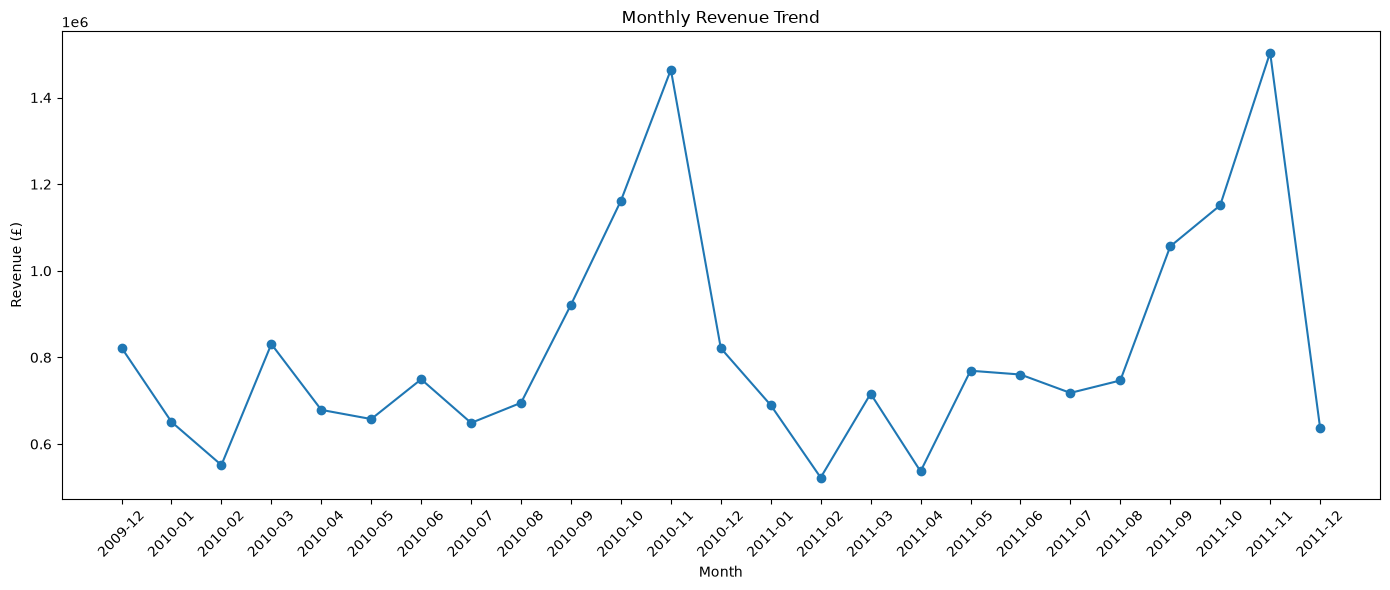

In [80]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_kpis["Month"].astype(str),
    monthly_kpis["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [81]:
# ============================================================
# STEP 15: CUSTOMER ANALYSIS
# ============================================================

# Only customers with a known Customer ID
customer_df = clean_df[
    clean_df["Customer ID"].notna()
].copy()

# Make sure date is datetime
customer_df["InvoiceDate"] = pd.to_datetime(
    customer_df["InvoiceDate"],
    errors="coerce"
)

# Monthly period
customer_df["Month"] = (
    customer_df["InvoiceDate"]
    .dt.to_period("M")
)

print("Customer dataset shape:", customer_df.shape)
print(
    "Unique identified customers:",
    customer_df["Customer ID"].nunique()
)

Customer dataset shape: (779495, 14)
Unique identified customers: 5881


In [82]:
first_purchase = (
    customer_df
    .groupby("Customer ID")["InvoiceDate"]
    .min()
    .reset_index(name="FirstPurchaseDate")
)

first_purchase.head()

,Customer ID,FirstPurchaseDate
0,12346.0,2009-12-14 08:34:00
1,12347.0,2010-10-31 14:20:00
2,12348.0,2010-09-27 14:59:00
3,12349.0,2010-04-29 13:20:00
4,12350.0,2011-02-02 16:01:00


In [83]:
customer_df = customer_df.merge(
    first_purchase,
    on="Customer ID",
    how="left"
)

customer_df["FirstPurchaseMonth"] = (
    customer_df["FirstPurchaseDate"]
    .dt.to_period("M")
)

customer_df["CustomerType"] = np.where(
    customer_df["Month"]
    == customer_df["FirstPurchaseMonth"],
    "New",
    "Repeat"
)

customer_df[
    [
        "Customer ID",
        "InvoiceDate",
        "FirstPurchaseDate",
        "CustomerType"
    ]
].head(20)

,Customer ID,InvoiceDate,FirstPurchaseDate,CustomerType
0,13085.0,2009-12-01 07:45:00,2009-12-01 07:45:00,New
1,13085.0,2009-12-01 07:45:00,2009-12-01 07:45:00,New
2,13085.0,2009-12-01 07:45:00,2009-12-01 07:45:00,New
3,13085.0,2009-12-01 07:45:00,2009-12-01 07:45:00,New
4,13085.0,2009-12-01 07:45:00,2009-12-01 07:45:00,New
5,13085.0,2009-12-01 07:45:00,2009-12-01 07:45:00,New
6,13085.0,2009-12-01 07:45:00,2009-12-01 07:45:00,New
7,13085.0,2009-12-01 07:45:00,2009-12-01 07:45:00,New
8,13085.0,2009-12-01 07:46:00,2009-12-01 07:45:00,New
9,13085.0,2009-12-01 07:46:00,2009-12-01 07:45:00,New


In [84]:
monthly_customer_type = (
    customer_df
    .groupby(
        ["Month", "CustomerType"]
    )["Customer ID"]
    .nunique()
    .reset_index(name="Customers")
)

customer_pivot = (
    monthly_customer_type
    .pivot(
        index="Month",
        columns="CustomerType",
        values="Customers"
    )
    .fillna(0)
    .reset_index()
)

customer_pivot

CustomerType,Month,New,Repeat
0,2009-12,955.0,0.0
1,2010-01,383.0,337.0
2,2010-02,376.0,398.0
3,2010-03,443.0,614.0
4,2010-04,294.0,648.0
5,2010-05,254.0,712.0
6,2010-06,270.0,771.0
7,2010-07,186.0,742.0
8,2010-08,162.0,749.0
9,2010-09,243.0,902.0


In [85]:
customer_pivot["Total_Customers"] = (
    customer_pivot.get("New", 0)
    + customer_pivot.get("Repeat", 0)
)

customer_pivot["Repeat_Customer_%"] = (
    customer_pivot["Repeat"]
    / customer_pivot["Total_Customers"]
    * 100
)

customer_pivot

CustomerType,Month,New,Repeat,Total_Customers,Repeat_Customer_%
0,2009-12,955.0,0.0,955.0,0.000000
1,2010-01,383.0,337.0,720.0,46.805556
2,2010-02,376.0,398.0,774.0,51.421189
3,2010-03,443.0,614.0,1057.0,58.088931
4,2010-04,294.0,648.0,942.0,68.789809
5,2010-05,254.0,712.0,966.0,73.706004
6,2010-06,270.0,771.0,1041.0,74.063401
7,2010-07,186.0,742.0,928.0,79.956897
8,2010-08,162.0,749.0,911.0,82.217344
9,2010-09,243.0,902.0,1145.0,78.777293


In [86]:
customer_revenue = (
    customer_df
    .groupby("Customer ID")["Revenue"]
    .sum()
    .reset_index()
    .sort_values(
        "Revenue",
        ascending=False
    )
)

customer_revenue.head(10)

,Customer ID,Revenue
5695,18102.0,580987.04
2279,14646.0,528602.52
1791,14156.0,313437.62
2541,14911.0,291420.81
5053,17450.0,244784.25
1332,13694.0,195640.69
5112,17511.0,172132.87
4064,16446.0,168472.50
4298,16684.0,147142.77
68,12415.0,144458.37


In [87]:
top_10_revenue = (
    customer_revenue
    .head(10)["Revenue"]
    .sum()
)

identified_customer_revenue = (
    customer_revenue["Revenue"].sum()
)

top_10_contribution = (
    top_10_revenue
    / identified_customer_revenue
    * 100
)

print(
    f"Top 10 customer revenue: "
    f"£{top_10_revenue:,.2f}"
)

print(
    f"Top 10 revenue contribution: "
    f"{top_10_contribution:.2f}%"
)

Top 10 customer revenue: £2,787,079.44
Top 10 revenue contribution: 16.04%


In [88]:
# ============================================================
# STEP 16: PRODUCT ANALYSIS
# ============================================================

product_df = clean_df[
    clean_df["StockCode"].notna()
].copy()

product_metrics = (
    product_df
    .groupby("StockCode")
    .agg(
        Revenue=("Revenue", "sum"),
        Units_Sold=(
            "Quantity",
            lambda x: x[x > 0].sum()
        ),
        Orders=("Invoice", "nunique"),
        Average_Price=("Price", "mean"),
        Description=("Description", "first")
    )
    .reset_index()
)

product_metrics = product_metrics.sort_values(
    "Revenue",
    ascending=False
)

print(
    "Unique products:",
    product_metrics["StockCode"].nunique()
)

product_metrics.head(20)

Unique products: 5298


,StockCode,Revenue,Units_Sold,Orders,Average_Price,Description
5281,M,339226.24,9636,790,391.082110,Manual
1751,22423,330590.32,26495,3931,14.136734,REGENCY CAKESTAND 3 TIER
5279,DOT,309854.11,2920,1422,217.900218,DOTCOM POSTAGE
4640,85123A,257724.71,98208,5373,3.071716,WHITE HANGING HEART T-LIGHT HOLDER
4610,85099B,180569.34,96764,3995,2.326868,JUMBO BAG RED WHITE SPOTTY
2914,23843,168469.60,80995,1,2.080000,"PAPER CRAFT , LITTLE BIRDIE"
3336,47566,148318.28,28248,2679,5.707627,PARTY BUNTING
4305,84879,129324.49,80090,2810,1.857078,ASSORTED COLOUR BIRD ORNAMENT
5283,POST,125682.42,10313,1858,29.355501,POSTAGE
1437,22086,117760.29,35113,2020,3.366671,PAPER CHAIN KIT 50'S CHRISTMAS


In [89]:
top_products_revenue = (
    product_metrics
    .head(10)
)

top_products_revenue

,StockCode,Revenue,Units_Sold,Orders,Average_Price,Description
5281,M,339226.24,9636,790,391.082110,Manual
1751,22423,330590.32,26495,3931,14.136734,REGENCY CAKESTAND 3 TIER
5279,DOT,309854.11,2920,1422,217.900218,DOTCOM POSTAGE
4640,85123A,257724.71,98208,5373,3.071716,WHITE HANGING HEART T-LIGHT HOLDER
4610,85099B,180569.34,96764,3995,2.326868,JUMBO BAG RED WHITE SPOTTY
2914,23843,168469.60,80995,1,2.080000,"PAPER CRAFT , LITTLE BIRDIE"
3336,47566,148318.28,28248,2679,5.707627,PARTY BUNTING
4305,84879,129324.49,80090,2810,1.857078,ASSORTED COLOUR BIRD ORNAMENT
5283,POST,125682.42,10313,1858,29.355501,POSTAGE
1437,22086,117760.29,35113,2020,3.366671,PAPER CHAIN KIT 50'S CHRISTMAS


In [90]:
top_products_units = (
    product_metrics
    .sort_values(
        "Units_Sold",
        ascending=False
    )
    .head(10)
)

top_products_units

,StockCode,Revenue,Units_Sold,Orders,Average_Price,Description
3802,84077,24445.61,106250,1021,0.282568,WORLD WAR 2 GLIDERS ASSTD DESIGNS
4640,85123A,257724.71,98208,5373,3.071716,WHITE HANGING HEART T-LIGHT HOLDER
4610,85099B,180569.34,96764,3995,2.326868,JUMBO BAG RED WHITE SPOTTY
692,21212,51825.15,94884,3118,0.708057,PACK OF 72 RETRO SPOT CAKE CASES
1545,22197,79520.20,88993,2331,1.029234,"POPCORN HOLDER , SMALL"
2914,23843,168469.60,80995,1,2.080000,"PAPER CRAFT , LITTLE BIRDIE"
4305,84879,129324.49,80090,2810,1.857078,ASSORTED COLOUR BIRD ORNAMENT
2468,23166,81700.92,78033,247,1.468480,MEDIUM CERAMIC TOP STORAGE JAR
135,17003,14766.42,70379,457,0.302073,BROCADE RING PURSE
1355,21977,28081.73,56061,1993,0.711244,PACK OF 60 PINK PAISLEY CAKE CASES


In [91]:
total_product_revenue = (
    product_metrics["Revenue"].sum()
)

top_10_product_revenue = (
    product_metrics
    .head(10)["Revenue"]
    .sum()
)

top_10_product_contribution = (
    top_10_product_revenue
    / total_product_revenue
    * 100
)

print(
    f"Total product revenue: "
    f"£{total_product_revenue:,.2f}"
)

print(
    f"Top 10 product revenue: "
    f"£{top_10_product_revenue:,.2f}"
)

print(
    f"Top 10 product contribution: "
    f"{top_10_product_contribution:.2f}%"
)

Total product revenue: £20,465,198.39
Top 10 product revenue: £2,107,519.80
Top 10 product contribution: 10.30%


In [92]:
top_20_product_revenue = (
    product_metrics
    .head(20)["Revenue"]
    .sum()
)

top_20_contribution = (
    top_20_product_revenue
    / total_product_revenue
    * 100
)

print(
    f"Top 20 product contribution: "
    f"{top_20_contribution:.2f}%"
)

Top 20 product contribution: 13.86%


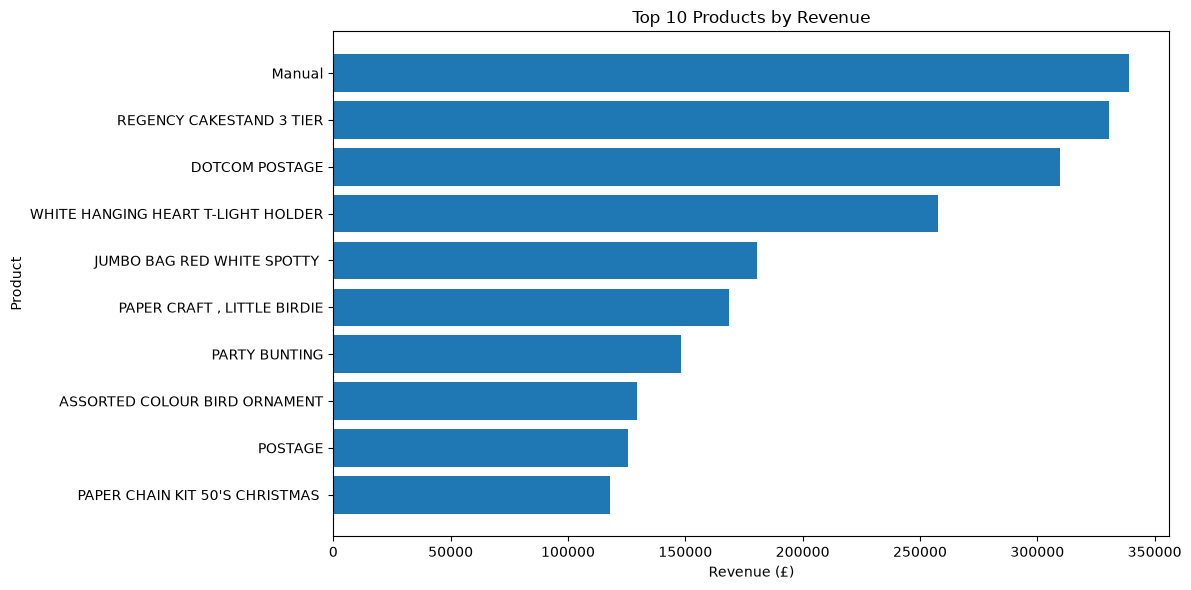

In [93]:
top_10_plot = (
    product_metrics
    .head(10)
    .sort_values("Revenue")
)

plt.figure(figsize=(12, 6))

plt.barh(
    top_10_plot["Description"],
    top_10_plot["Revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [94]:
# ============================================================
# STEP 17: COUNTRY ANALYSIS
# ============================================================

country_metrics = (
    clean_df
    .groupby("Country")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("Invoice", "nunique"),
        Customers=("Customer ID", "nunique"),
        Units_Sold=(
            "Quantity",
            lambda x: x[x > 0].sum()
        )
    )
    .reset_index()
)

# Average Order Value
country_metrics["AOV"] = (
    country_metrics["Revenue"]
    / country_metrics["Orders"]
)

# Revenue share
country_metrics["Revenue_Share_%"] = (
    country_metrics["Revenue"]
    / country_metrics["Revenue"].sum()
    * 100
)

# Sort by revenue
country_metrics = country_metrics.sort_values(
    "Revenue",
    ascending=False
)

country_metrics

,Country,Revenue,Orders,Customers,Units_Sold,AOV,Revenue_Share_%
40,United Kingdom,1.739913e+07,41787,5353,9437243,416.376721,85.018155
11,EIRE,6.587673e+05,626,5,336604,1052.343946,3.218964
26,Netherlands,5.540381e+05,229,22,384519,2419.380306,2.707221
15,Germany,4.250197e+05,789,107,225173,538.681510,2.076793
14,France,3.504561e+05,622,95,271902,563.434228,1.712449
0,Australia,1.692835e+05,95,15,104067,1781.931158,0.827177
34,Spain,1.083325e+05,154,41,50318,703.457727,0.529350
36,Switzerland,1.006856e+05,93,22,52763,1082.640753,0.491984
35,Sweden,9.186982e+04,105,19,88633,874.950667,0.448908
10,Denmark,6.858069e+04,43,12,237471,1594.899767,0.335109


In [95]:
top_countries = (
    country_metrics
    .head(10)
)

top_countries

,Country,Revenue,Orders,Customers,Units_Sold,AOV,Revenue_Share_%
40,United Kingdom,1.739913e+07,41787,5353,9437243,416.376721,85.018155
11,EIRE,6.587673e+05,626,5,336604,1052.343946,3.218964
26,Netherlands,5.540381e+05,229,22,384519,2419.380306,2.707221
15,Germany,4.250197e+05,789,107,225173,538.681510,2.076793
14,France,3.504561e+05,622,95,271902,563.434228,1.712449
0,Australia,1.692835e+05,95,15,104067,1781.931158,0.827177
34,Spain,1.083325e+05,154,41,50318,703.457727,0.529350
36,Switzerland,1.006856e+05,93,22,52763,1082.640753,0.491984
35,Sweden,9.186982e+04,105,19,88633,874.950667,0.448908
10,Denmark,6.858069e+04,43,12,237471,1594.899767,0.335109


In [96]:
uk_metrics = country_metrics[
    country_metrics["Country"] == "United Kingdom"
]

uk_metrics

,Country,Revenue,Orders,Customers,Units_Sold,AOV,Revenue_Share_%
40,United Kingdom,1.739913e+07,41787,5353,9437243,416.376721,85.018155


In [97]:
uk_revenue_share = (
    uk_metrics["Revenue"].iloc[0]
    / country_metrics["Revenue"].sum()
    * 100
)

print(
    f"United Kingdom revenue share: "
    f"{uk_revenue_share:.2f}%"
)

United Kingdom revenue share: 85.02%


In [98]:
top_10_country_revenue = (
    country_metrics
    .head(10)["Revenue"]
    .sum()
)

top_10_country_share = (
    top_10_country_revenue
    / country_metrics["Revenue"].sum()
    * 100
)

print(
    f"Top 10 countries revenue: "
    f"£{top_10_country_revenue:,.2f}"
)

print(
    f"Top 10 countries revenue share: "
    f"{top_10_country_share:.2f}%"
)

Top 10 countries revenue: £19,926,167.31
Top 10 countries revenue share: 97.37%


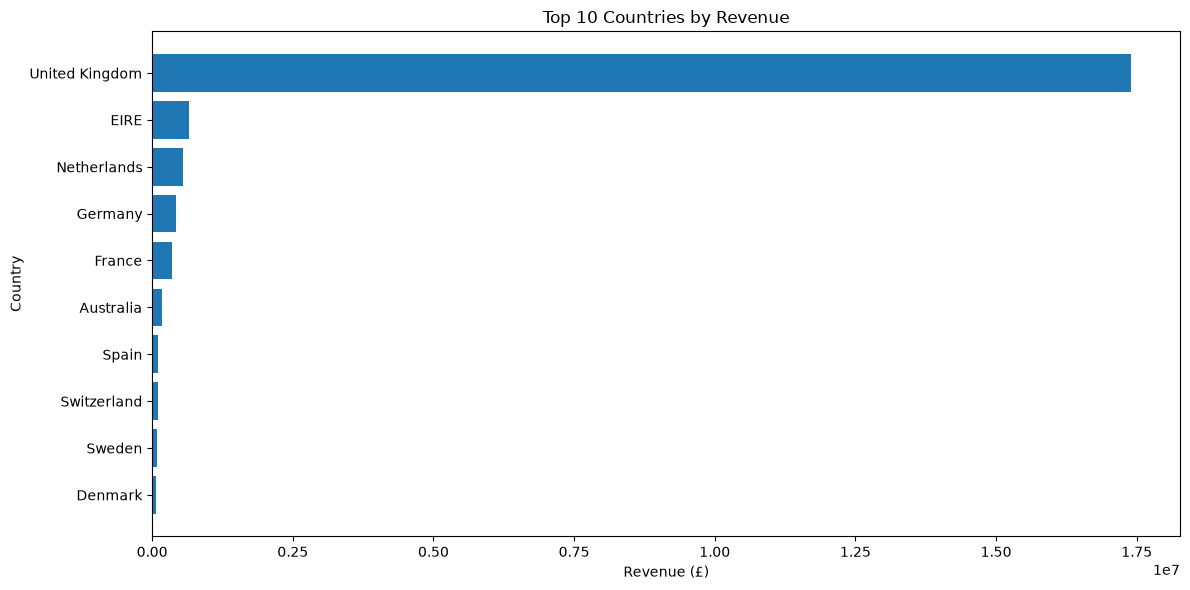

In [99]:
top_10_plot = (
    country_metrics
    .head(10)
    .sort_values("Revenue")
)

plt.figure(figsize=(12, 6))

plt.barh(
    top_10_plot["Country"],
    top_10_plot["Revenue"]
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [ ]:
top_products_units = (
    product_metrics
    .sort_values(
        "Units_Sold",
        ascending=False
    )
    .head(10)
)

top_products_units

,StockCode,Revenue,Units_Sold,Orders,Average_Price,Description
3802,84077,24445.61,106250,1021,0.282568,WORLD WAR 2 GLIDERS ASSTD DESIGNS
4640,85123A,257724.71,98208,5373,3.071716,WHITE HANGING HEART T-LIGHT HOLDER
4610,85099B,180569.34,96764,3995,2.326868,JUMBO BAG RED WHITE SPOTTY
692,21212,51825.15,94884,3118,0.708057,PACK OF 72 RETRO SPOT CAKE CASES
1545,22197,79520.20,88993,2331,1.029234,"POPCORN HOLDER , SMALL"
2914,23843,168469.60,80995,1,2.080000,"PAPER CRAFT , LITTLE BIRDIE"
4305,84879,129324.49,80090,2810,1.857078,ASSORTED COLOUR BIRD ORNAMENT
2468,23166,81700.92,78033,247,1.468480,MEDIUM CERAMIC TOP STORAGE JAR
135,17003,14766.42,70379,457,0.302073,BROCADE RING PURSE
1355,21977,28081.73,56061,1993,0.711244,PACK OF 60 PINK PAISLEY CAKE CASES


In [100]:
# ============================================================
# STEP 18: TIME ANALYSIS
# ============================================================

time_df = clean_df.copy()

time_df["InvoiceDate"] = pd.to_datetime(
    time_df["InvoiceDate"],
    errors="coerce"
)

time_df["Year"] = time_df["InvoiceDate"].dt.year
time_df["Month"] = time_df["InvoiceDate"].dt.month
time_df["Day"] = time_df["InvoiceDate"].dt.day
time_df["Hour"] = time_df["InvoiceDate"].dt.hour

time_df["Day_Name"] = (
    time_df["InvoiceDate"]
    .dt.day_name()
)

time_df["Month_Name"] = (
    time_df["InvoiceDate"]
    .dt.month_name()
)

time_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancelled,is_return,is_zero_price,is_bad_debt,Revenue,Month,Year,Day,Hour,Day_Name,Month_Name
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,False,False,False,83.4,12,2009,1,7,Tuesday,December
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,False,False,False,81.0,12,2009,1,7,Tuesday,December
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,False,False,False,81.0,12,2009,1,7,Tuesday,December
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,False,False,False,100.8,12,2009,1,7,Tuesday,December
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,False,False,False,30.0,12,2009,1,7,Tuesday,December


In [101]:
weekday_metrics = (
    time_df
    .groupby("Day_Name")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("Invoice", "nunique"),
        Customers=("Customer ID", "nunique"),
        Units_Sold=(
            "Quantity",
            lambda x: x[x > 0].sum()
        )
    )
    .reset_index()
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_metrics["Day_Name"] = pd.Categorical(
    weekday_metrics["Day_Name"],
    categories=weekday_order,
    ordered=True
)

weekday_metrics = (
    weekday_metrics
    .sort_values("Day_Name")
)

weekday_metrics["AOV"] = (
    weekday_metrics["Revenue"]
    / weekday_metrics["Orders"]
)

weekday_metrics

,Day_Name,Revenue,Orders,Customers,Units_Sold,AOV
1,Monday,3581594.176,7253,2549,2066882,493.808655
5,Tuesday,4078149.962,8505,2754,2188022,479.500289
6,Wednesday,3488444.333,8161,2755,2022286,427.453049
4,Thursday,4195212.762,9312,3000,2402814,450.516834
0,Friday,3312846.823,7228,2441,1743433,458.335200
2,Saturday,9803.050,32,26,5119,306.345313
3,Sunday,1799147.282,4839,2128,1027350,371.801464


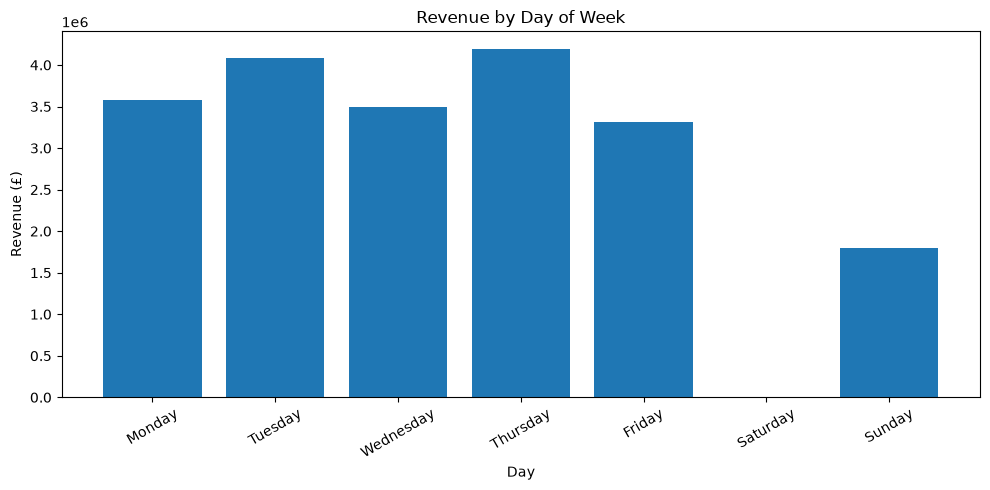

In [102]:
plt.figure(figsize=(10, 5))

plt.bar(
    weekday_metrics["Day_Name"],
    weekday_metrics["Revenue"]
)

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [103]:
hourly_metrics = (
    time_df
    .groupby("Hour")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("Invoice", "nunique"),
        Customers=("Customer ID", "nunique"),
        Units_Sold=(
            "Quantity",
            lambda x: x[x > 0].sum()
        )
    )
    .reset_index()
)

hourly_metrics["AOV"] = (
    hourly_metrics["Revenue"]
    / hourly_metrics["Orders"]
)

hourly_metrics

,Hour,Revenue,Orders,Customers,Units_Sold,AOV
0,6,4.250,1,1,1,4.250000
1,7,75765.570,77,67,44875,983.968442
2,8,528185.570,1003,690,295781,526.605753
3,9,1769631.031,3044,1391,927239,581.350536
4,10,2581131.333,5183,2028,1518203,497.999485
5,11,2535325.463,5516,2139,1477269,459.631157
6,12,2850377.671,7055,2589,1685066,404.022349
7,13,2548467.544,6185,2570,1569768,412.040023
8,14,2310622.671,5653,2343,1220630,408.742733
9,15,2394943.792,5353,2119,1334551,447.402166


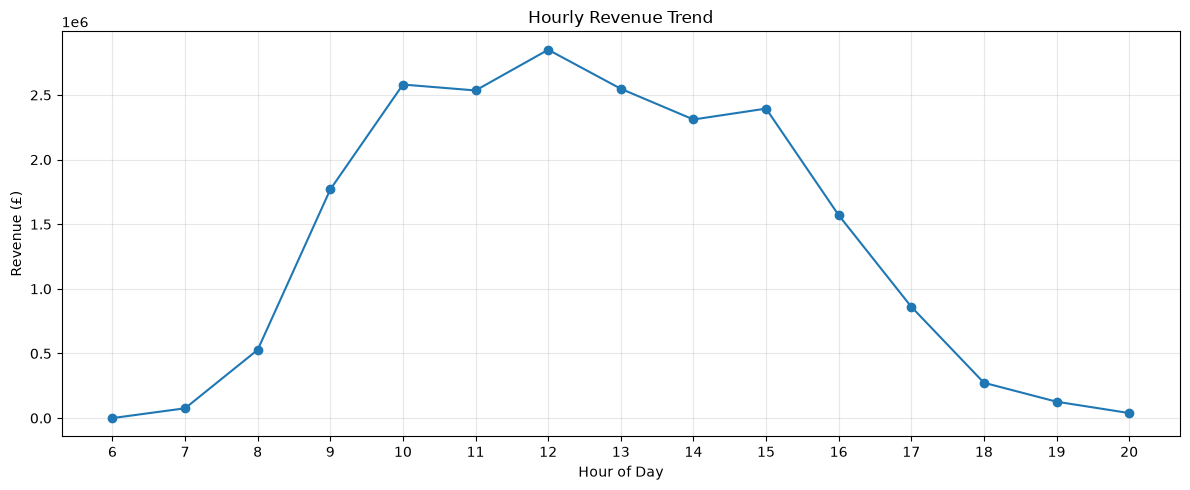

In [104]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_metrics["Hour"],
    hourly_metrics["Revenue"],
    marker="o"
)

plt.title("Hourly Revenue Trend")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue (£)")

plt.xticks(
    range(
        int(hourly_metrics["Hour"].min()),
        int(hourly_metrics["Hour"].max()) + 1
    )
)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [105]:
best_weekday = weekday_metrics.loc[
    weekday_metrics["Revenue"].idxmax()
]

worst_weekday = weekday_metrics.loc[
    weekday_metrics["Revenue"].idxmin()
]

print("BEST REVENUE DAY")
print(best_weekday)

print("\nWORST REVENUE DAY")
print(worst_weekday)

BEST REVENUE DAY
Day_Name         Thursday
Revenue       4195212.762
Orders               9312
Customers            3000
Units_Sold        2402814
AOV            450.516834
Name: 4, dtype: object

WORST REVENUE DAY
Day_Name        Saturday
Revenue          9803.05
Orders                32
Customers             26
Units_Sold          5119
AOV           306.345313
Name: 2, dtype: object


In [106]:
best_hour = hourly_metrics.loc[
    hourly_metrics["Revenue"].idxmax()
]

worst_hour = hourly_metrics.loc[
    hourly_metrics["Revenue"].idxmin()
]

print("BEST REVENUE HOUR")
print(best_hour)

print("\nWORST REVENUE HOUR")
print(worst_hour)

BEST REVENUE HOUR
Hour          1.200000e+01
Revenue       2.850378e+06
Orders        7.055000e+03
Customers     2.589000e+03
Units_Sold    1.685066e+06
AOV           4.040223e+02
Name: 6, dtype: float64

WORST REVENUE HOUR
Hour          6.00
Revenue       4.25
Orders        1.00
Customers     1.00
Units_Sold    1.00
AOV           4.25
Name: 0, dtype: float64


In [107]:
# ============================================================
# STEP 19: RFM CUSTOMER ANALYSIS
# ============================================================

rfm_df = clean_df.copy()

# Make sure date is datetime
rfm_df["InvoiceDate"] = pd.to_datetime(
    rfm_df["InvoiceDate"],
    errors="coerce"
)

# Remove transactions without Customer ID
rfm_df = rfm_df[
    rfm_df["Customer ID"].notna()
].copy()

# ------------------------------------------------------------
# Reference date
# ------------------------------------------------------------

reference_date = rfm_df["InvoiceDate"].max()

print("Reference date:", reference_date)

# ------------------------------------------------------------
# RFM metrics
# ------------------------------------------------------------

rfm = (
    rfm_df
    .groupby("Customer ID")
    .agg(
        LastPurchaseDate=("InvoiceDate", "max"),
        Frequency=("Invoice", "nunique"),
        Monetary=("Revenue", "sum")
    )
    .reset_index()
)

# Recency = days since last purchase
rfm["Recency"] = (
    reference_date - rfm["LastPurchaseDate"]
).dt.days

# Arrange columns
rfm = rfm[
    [
        "Customer ID",
        "Recency",
        "Frequency",
        "Monetary",
        "LastPurchaseDate"
    ]
]

rfm.head(10)

Reference date: 2011-12-09 12:50:00


,Customer ID,Recency,Frequency,Monetary,LastPurchaseDate
0,12346.0,325,12,77556.46,2011-01-18 10:01:00
1,12347.0,1,8,4921.53,2011-12-07 15:52:00
2,12348.0,74,5,2019.40,2011-09-25 13:13:00
3,12349.0,18,4,4428.69,2011-11-21 09:51:00
4,12350.0,309,1,334.40,2011-02-02 16:01:00
5,12351.0,374,1,300.93,2010-11-29 15:23:00
6,12352.0,35,10,2849.84,2011-11-03 14:37:00
7,12353.0,203,2,406.76,2011-05-19 17:47:00
8,12354.0,231,1,1079.40,2011-04-21 13:11:00
9,12355.0,213,2,947.61,2011-05-09 13:49:00


In [109]:
print("=" * 60)
print("RFM SUMMARY")
print("=" * 60)

print(f"Customers analysed: {len(rfm):,}")

print("\nRecency:")
print(rfm["Recency"].describe())

print("\nFrequency:")
print(rfm["Frequency"].describe())

print("\nMonetary:")
print(rfm["Monetary"].describe())

RFM SUMMARY
Customers analysed: 5,881

Recency:
count    5881.000000
mean      200.457745
std       209.474135
min         0.000000
25%        25.000000
50%        95.000000
75%       379.000000
max       738.000000
Name: Recency, dtype: float64

Frequency:
count    5881.000000
mean        6.287196
std        13.012879
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       398.000000
Name: Frequency, dtype: float64

Monetary:
count      5881.000000
mean       2954.396237
std       14437.322635
min           0.000000
25%         341.900000
50%         865.600000
75%        2247.720000
max      580987.040000
Name: Monetary, dtype: float64


In [110]:
top_customers = (
    rfm
    .sort_values("Monetary", ascending=False)
    .head(20)
)

top_customers

,Customer ID,Recency,Frequency,Monetary,LastPurchaseDate
5695,18102.0,0,145,580987.04,2011-12-09 11:50:00
2279,14646.0,1,152,528602.52,2011-12-08 12:12:00
1791,14156.0,9,156,313437.62,2011-11-30 10:54:00
2541,14911.0,0,398,291420.81,2011-12-08 15:54:00
5053,17450.0,7,51,244784.25,2011-12-01 13:29:00
1332,13694.0,3,143,195640.69,2011-12-06 09:32:00
5112,17511.0,2,60,172132.87,2011-12-07 10:12:00
4064,16446.0,0,2,168472.50,2011-12-09 09:15:00
4298,16684.0,3,55,147142.77,2011-12-05 14:06:00
68,12415.0,23,28,144458.37,2011-11-15 14:22:00


In [111]:
top_frequency = (
    rfm
    .sort_values("Frequency", ascending=False)
    .head(20)
)

top_frequency

,Customer ID,Recency,Frequency,Monetary,LastPurchaseDate
2541,14911.0,0,398,291420.810,2011-12-08 15:54:00
400,12748.0,0,337,53539.640,2011-12-09 12:20:00
5436,17841.0,1,211,68545.250,2011-12-08 12:07:00
2938,15311.0,0,208,114966.420,2011-12-09 12:00:00
739,13089.0,2,203,113416.910,2011-12-07 09:02:00
2239,14606.0,0,192,29951.370,2011-12-08 19:28:00
1791,14156.0,9,156,313437.620,2011-11-30 10:54:00
5445,17850.0,371,155,51208.870,2010-12-02 15:27:00
2279,14646.0,1,152,528602.520,2011-12-08 12:12:00
5695,18102.0,0,145,580987.040,2011-12-09 11:50:00


In [112]:
most_recent = (
    rfm
    .sort_values("Recency", ascending=True)
    .head(20)
)

most_recent

,Customer ID,Recency,Frequency,Monetary,LastPurchaseDate
4019,16401.0,0,23,6849.15,2011-12-08 18:15:00
76,12423.0,0,10,2622.39,2011-12-09 10:10:00
1176,13536.0,0,7,3444.39,2011-12-08 16:38:00
1162,13521.0,0,3,1071.73,2011-12-08 13:50:00
2938,15311.0,0,208,114966.42,2011-12-09 12:00:00
1151,13510.0,0,11,4558.29,2011-12-08 13:46:00
3319,15694.0,0,24,9978.48,2011-12-09 09:44:00
3940,16322.0,0,2,326.75,2011-12-08 15:41:00
946,13298.0,0,1,360.00,2011-12-08 13:11:00
1687,14051.0,0,37,21770.98,2011-12-09 10:20:00


In [113]:
# ============================================================
# RFM SCORING
# ============================================================

# Make a copy
rfm_scored = rfm.copy()

# ------------------------------------------------------------
# Recency Score
# Lower recency = better customer
# ------------------------------------------------------------

rfm_scored["R_Score"] = pd.qcut(
    rfm_scored["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

# ------------------------------------------------------------
# Frequency Score
# Higher frequency = better customer
# ------------------------------------------------------------

rfm_scored["F_Score"] = pd.qcut(
    rfm_scored["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# ------------------------------------------------------------
# Monetary Score
# Higher monetary value = better customer
# ------------------------------------------------------------

rfm_scored["M_Score"] = pd.qcut(
    rfm_scored["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# ------------------------------------------------------------
# Overall RFM Score
# ------------------------------------------------------------

rfm_scored["RFM_Score"] = (
    rfm_scored["R_Score"].astype(str)
    + rfm_scored["F_Score"].astype(str)
    + rfm_scored["M_Score"].astype(str)
)

# Numeric combined score
rfm_scored["RFM_Total"] = (
    rfm_scored["R_Score"]
    + rfm_scored["F_Score"]
    + rfm_scored["M_Score"]
)

rfm_scored.head(20)

,Customer ID,Recency,Frequency,Monetary,LastPurchaseDate,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,12346.0,325,12,77556.46,2011-01-18 10:01:00,2,5,5,255,12
1,12347.0,1,8,4921.53,2011-12-07 15:52:00,5,4,5,545,14
2,12348.0,74,5,2019.40,2011-09-25 13:13:00,3,4,4,344,11
3,12349.0,18,4,4428.69,2011-11-21 09:51:00,5,3,5,535,13
4,12350.0,309,1,334.40,2011-02-02 16:01:00,2,1,2,212,5
5,12351.0,374,1,300.93,2010-11-29 15:23:00,2,1,2,212,5
6,12352.0,35,10,2849.84,2011-11-03 14:37:00,4,5,4,454,13
7,12353.0,203,2,406.76,2011-05-19 17:47:00,2,2,2,222,6
8,12354.0,231,1,1079.40,2011-04-21 13:11:00,2,1,3,213,6
9,12355.0,213,2,947.61,2011-05-09 13:49:00,2,2,3,223,7


In [114]:
# ============================================================
# CUSTOMER SEGMENTATION
# ============================================================

def assign_segment(row):

    R = row["R_Score"]
    F = row["F_Score"]
    M = row["M_Score"]

    # --------------------------------------------------------
    # Champions
    # --------------------------------------------------------
    if R >= 4 and F >= 4 and M >= 4:
        return "Champions"

    # --------------------------------------------------------
    # Loyal Customers
    # --------------------------------------------------------
    elif R >= 3 and F >= 4:
        return "Loyal Customers"

    # --------------------------------------------------------
    # Big Spenders
    # --------------------------------------------------------
    elif R >= 3 and M >= 4:
        return "Big Spenders"

    # --------------------------------------------------------
    # New Customers
    # --------------------------------------------------------
    elif R >= 4 and F <= 2:
        return "New Customers"

    # --------------------------------------------------------
    # At Risk
    # --------------------------------------------------------
    elif R <= 2 and F >= 3 and M >= 3:
        return "At Risk"

    # --------------------------------------------------------
    # Hibernating
    # --------------------------------------------------------
    elif R <= 2 and F <= 2:
        return "Hibernating"

    # --------------------------------------------------------
    # Potential Loyalists
    # --------------------------------------------------------
    elif R >= 3 and F >= 3:
        return "Potential Loyalists"

    # --------------------------------------------------------
    # Others
    # --------------------------------------------------------
    else:
        return "Others"


rfm_scored["Segment"] = (
    rfm_scored.apply(
        assign_segment,
        axis=1
    )
)

rfm_scored.head(20)

,Customer ID,Recency,Frequency,Monetary,LastPurchaseDate,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Segment
0,12346.0,325,12,77556.46,2011-01-18 10:01:00,2,5,5,255,12,At Risk
1,12347.0,1,8,4921.53,2011-12-07 15:52:00,5,4,5,545,14,Champions
2,12348.0,74,5,2019.40,2011-09-25 13:13:00,3,4,4,344,11,Loyal Customers
3,12349.0,18,4,4428.69,2011-11-21 09:51:00,5,3,5,535,13,Big Spenders
4,12350.0,309,1,334.40,2011-02-02 16:01:00,2,1,2,212,5,Hibernating
5,12351.0,374,1,300.93,2010-11-29 15:23:00,2,1,2,212,5,Hibernating
6,12352.0,35,10,2849.84,2011-11-03 14:37:00,4,5,4,454,13,Champions
7,12353.0,203,2,406.76,2011-05-19 17:47:00,2,2,2,222,6,Hibernating
8,12354.0,231,1,1079.40,2011-04-21 13:11:00,2,1,3,213,6,Hibernating
9,12355.0,213,2,947.61,2011-05-09 13:49:00,2,2,3,223,7,Hibernating


In [115]:
# ============================================================
# SEGMENT SUMMARY
# ============================================================

segment_summary = (
    rfm_scored
    .groupby("Segment")
    .agg(
        Customers=("Customer ID", "count"),
        Revenue=("Monetary", "sum"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean")
    )
    .reset_index()
)

# Customer percentage
segment_summary["Customer_Share_%"] = (
    segment_summary["Customers"]
    / len(rfm_scored)
    * 100
)

# Revenue percentage
segment_summary["Revenue_Share_%"] = (
    segment_summary["Revenue"]
    / rfm_scored["Monetary"].sum()
    * 100
)

# Sort by revenue
segment_summary = (
    segment_summary
    .sort_values(
        "Revenue",
        ascending=False
    )
)

segment_summary

,Segment,Customers,Revenue,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Share_%,Revenue_Share_%
2,Champions,1290,1.182343e+07,18.749612,17.142636,9165.451329,21.935045,68.049297
4,Loyal Customers,707,1.891826e+06,82.968883,7.768034,2675.850120,12.021765,10.888330
0,At Risk,617,1.506647e+06,358.231767,5.620746,2441.891608,10.491413,8.671448
1,Big Spenders,255,7.571579e+05,59.364706,3.050980,2969.246518,4.335997,4.357792
3,Hibernating,1527,6.547848e+05,458.196464,1.252128,428.804743,25.964972,3.768588
7,Potential Loyalists,507,3.413805e+05,56.824458,3.017751,673.334302,8.620983,1.964802
6,Others,562,2.239908e+05,213.588968,1.928826,398.560180,9.556198,1.289170
5,New Customers,416,1.755849e+05,27.322115,1.435096,422.079038,7.073627,1.010572


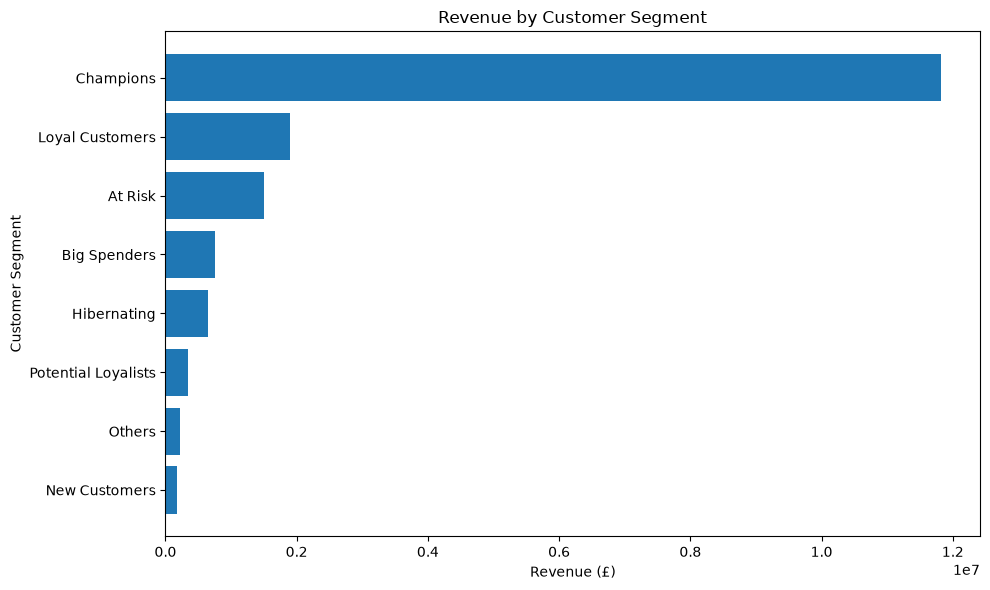

In [116]:
import matplotlib.pyplot as plt

segment_plot = (
    segment_summary
    .sort_values(
        "Revenue",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    segment_plot["Segment"],
    segment_plot["Revenue"]
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

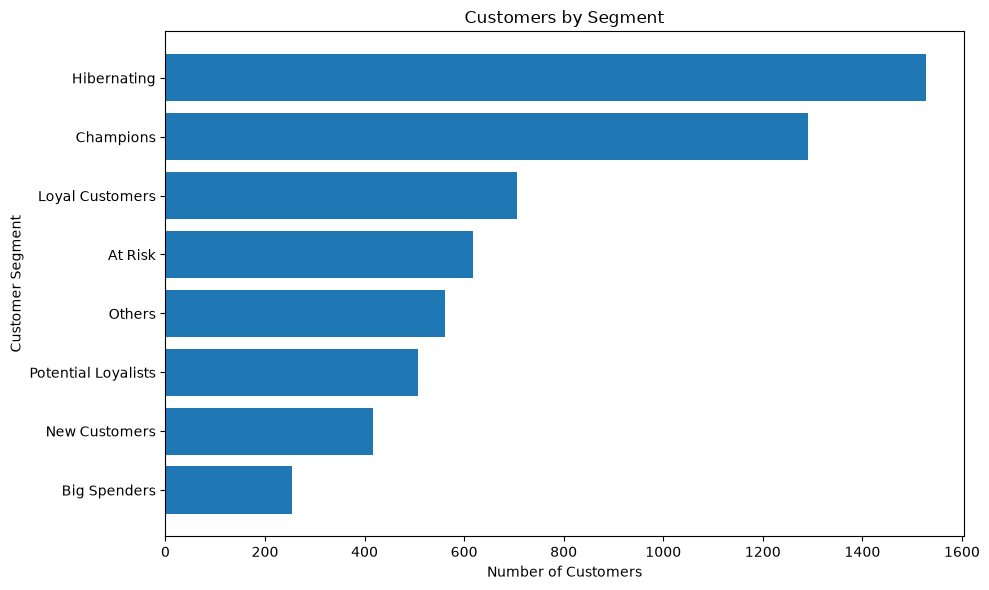

In [117]:
segment_count_plot = (
    segment_summary
    .sort_values(
        "Customers",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    segment_count_plot["Segment"],
    segment_count_plot["Customers"]
)

plt.title("Customers by Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

In [118]:
# ============================================================
# TOP CHAMPIONS
# ============================================================

champions = (
    rfm_scored[
        rfm_scored["Segment"] == "Champions"
    ]
    .sort_values(
        "Monetary",
        ascending=False
    )
    .head(20)
)

champions

,Customer ID,Recency,Frequency,Monetary,LastPurchaseDate,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Segment
5695,18102.0,0,145,580987.04,2011-12-09 11:50:00,5,5,5,555,15,Champions
2279,14646.0,1,152,528602.52,2011-12-08 12:12:00,5,5,5,555,15,Champions
1791,14156.0,9,156,313437.62,2011-11-30 10:54:00,5,5,5,555,15,Champions
2541,14911.0,0,398,291420.81,2011-12-08 15:54:00,5,5,5,555,15,Champions
5053,17450.0,7,51,244784.25,2011-12-01 13:29:00,5,5,5,555,15,Champions
1332,13694.0,3,143,195640.69,2011-12-06 09:32:00,5,5,5,555,15,Champions
5112,17511.0,2,60,172132.87,2011-12-07 10:12:00,5,5,5,555,15,Champions
4298,16684.0,3,55,147142.77,2011-12-05 14:06:00,5,5,5,555,15,Champions
68,12415.0,23,28,144458.37,2011-11-15 14:22:00,4,5,5,455,14,Champions
2688,15061.0,3,127,126389.02,2011-12-06 12:06:00,5,5,5,555,15,Champions


In [120]:
# ============================================================
# SAVE RFM DATA
# ============================================================

from pathlib import Path

# Find project root relative to notebook
project_root = Path.cwd().parent

# If notebook is already running from project root
if not (project_root / "data").exists():
    project_root = Path.cwd()

output_dir = project_root / "data" / "processed"

# Create directory if it doesn't exist
output_dir.mkdir(
    parents=True,
    exist_ok=True
)

rfm_output = output_dir / "customer_rfm.csv"

rfm_scored.to_csv(
    rfm_output,
    index=False
)

print("=" * 60)
print("RFM DATA SAVED")
print("=" * 60)
print(f"File: {rfm_output}")
print(f"Rows: {len(rfm_scored)}")
print(f"Columns: {len(rfm_scored.columns)}")

RFM DATA SAVED
File: c:\Users\rathi\OneDrive\Desktop\business-investigator\data\processed\customer_rfm.csv
Rows: 5881
Columns: 11
